# Scratch — classify, then discover

One pipeline. Offline `flow` / `subflow` labels are on the sample for inspection; they are not inputs to classification or clustering.

```text
1. classify each conversation against existing INTENTS
   (conversation-centroid  and  intent guideline text)
2. BERTopic on conversations that do not fit
   → cohesive topic with enough members = candidate new intent
3. within each assigned known intent, classify against existing SUBFLOWS
   (same two matchers)
4. BERTopic on unclassified leftovers inside that intent
   → cohesive topic = candidate new subflow
5. same clustering on each candidate new intent
   (no existing subflows there, so everyone is unclassified)
```

Thresholds below are round numbers, not tuned. Change them and re-run.

In [2]:
from dotenv import load_dotenv

load_dotenv(".env")

False

In [35]:
from __future__ import annotations

import json
import os
import sys
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

def _find_root() -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / "src" / "playbook" / "config.py").exists():
            return candidate
    raise RuntimeError("Could not find worktree root containing src/playbook")


ROOT = _find_root()
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from playbook.config import ABCD_JSON, GUIDELINES_JSON, KB_JSON

# --- knobs (untuned) ---
MIN_SIM = 0.60
MIN_MARGIN = 0.05
# A conversation is assigned if it fits this matcher set:
#   "centroid" | "guideline" | "either" | "both"
FIT_RULE = "either"
MIN_CLUSTER_SIZE = 5
MIN_TOPIC_N = 5
MIN_TO_CLUSTER = 5
PER_SEED = 15
PER_PROBE = 15
MIN_OPENING = 25

"""
MIN_SIM = 0.60 — Cosine similarity to the best prototype must be at least 0.60. Below that, the nearest label is treated as a weak match (too far from any known playbook item).

MIN_MARGIN = 0.10 — The best prototype must beat the second-best by at least 0.10. That blocks “close call” assignments (e.g. almost as similar to account_access as to order_issue). With only one prototype, margin is just sim.

FIT_RULE = "either" — How the two matchers vote:

rule	           assigned if
"centroid"         conversation looks like the seed-conversation centroid
"guideline"        conversation looks like the KB guideline text
"either" (current) either matcher fits
"both"             both must fit

Unassigned tickets go to clustering (candidate new intent / new subflow). If both matchers fit but disagree on the label, resolve_label keeps the one with the higher similarity.

These are the sampling and clustering knobs at the top of scratch_multi_intent_eda.ipynb. Three build the fake week; three decide when BERTopic is allowed to call something a topic.

Sampling the week

MIN_OPENING = 25 — Drop conversations whose first customer message is shorter than 25 characters ("hi", "ok", etc.). pick() only keeps tickets that pass this, then takes the first N by convo_id.

PER_SEED = 6 — How many conversations to take from each known playbook subflow (3 account-access + 4 order-issue). That is 7 × 6 = 42 seed tickets.

PER_PROBE = 8 — How many conversations to take for each held-out probe: the new order subflow (status_payment_method) and the new intent (troubleshoot_site / slow_speed).

Clustering / “is this a real topic?”

MIN_TO_CLUSTER = 5 — Do not run BERTopic at all if the leftover pile is smaller than this. Those items stay unclustered (topic = -1). Used when discovering candidate new intents or new subflows.

MIN_CLUSTER_SIZE = 5 — HDBSCAN’s min_cluster_size: the smallest group BERTopic is allowed to form. Smaller blobs become noise.

MIN_TOPIC_N = 5 — After clustering, a topic is cohesive_enough only if it is not noise (topic != -1) and has at least 5 members. Only those become “candidate new intent” or “candidate new subflow.”
"""


SEED_SUBFLOWS = {
    "account_access": ["recover_username", "recover_password", "reset_2fa"],
    "order_issue": [
        "status_mystery_fee",
        "status_delivery_time",
        "manage_upgrade",
        "manage_cancel",
    ],
}
INTENT_NAMES = list(SEED_SUBFLOWS)
INTENT_GUIDELINE_TITLE = {
    "account_access": "Account Access",
    "order_issue": "Order Issue",
}
SUBFLOW_GUIDELINE_TITLE = {
    "recover_username": "Recover Username",
    "recover_password": "Recover Password",
    "reset_2fa": "Reset Two-Factor Auth",
    "status_mystery_fee": "Status Mystery Fee",
    "status_delivery_time": "Status Delivery Time",
    "manage_upgrade": "Manage Upgrade",
    "manage_cancel": "Manage Cancel",
}
PROBE_SUBFLOW = ("order_issue", "status_payment_method")
PROBE_INTENT = ("troubleshoot_site", "slow_speed")
NOISE_PAIRS = [
    ("shipping_issue", "missing"),
    ("shipping_issue", "cost"),
    ("product_defect", "return_stain"),
    ("product_defect", "refund_initiate"),
    ("purchase_dispute", "promo_code_invalid"),
    ("purchase_dispute", "out_of_stock_general"),
    ("subscription_inquiry", "manage_pay_bill"),
    ("manage_account", "manage_change_address"),
    ("storewide_query", "pricing_3"),
    ("single_item_query", "boots_how_2"),
]

print("ROOT", ROOT)
print("MIN_SIM", MIN_SIM, "MIN_MARGIN", MIN_MARGIN, "FIT_RULE", FIT_RULE)

ROOT C:\Users\doste\.cursor\worktrees\phase-01-data-topic-eda-a7c3e91b
MIN_SIM 0.6 MIN_MARGIN 0.05 FIT_RULE either


## 1. Sample

Seed = all `account_access` subflows + four `order_issue` subflows. Then noise singletons, a held-out order subflow, and a held-out site-troubleshooting subflow. First N by `convo_id` after dropping short openings.

In [4]:
raw = json.loads(ABCD_JSON.read_text(encoding="utf-8"))
guidelines = json.loads(GUIDELINES_JSON.read_text(encoding="utf-8"))
kb = json.loads(KB_JSON.read_text(encoding="utf-8"))
all_convos = [item for split in raw.values() for item in split]


def first_customer(item: dict) -> str:
    for speaker, text in item["original"]:
        if speaker == "customer":
            return text.strip()
    return ""


def conversation_text(item: dict) -> str:
    return "\n".join(
        text for speaker, text in item["original"] if speaker in {"customer", "agent"} and text
    )


def action_names(item: dict) -> tuple[str, ...]:
    names = []
    for turn in item.get("delexed") or []:
        if turn.get("speaker") == "action":
            targets = turn.get("targets") or []
            if len(targets) > 2 and targets[2]:
                names.append(str(targets[2]))
    return tuple(names)


def pick(flow: str, subflow: str, n: int) -> list[dict]:
    items = [
        c
        for c in all_convos
        if c["scenario"]["flow"] == flow
        and c["scenario"]["subflow"] == subflow
        and len(first_customer(c)) >= MIN_OPENING
    ]
    items = sorted(items, key=lambda c: int(c["convo_id"]))
    if len(items) < n:
        raise ValueError(f"{flow}/{subflow}: {len(items)} after filter, need {n}")
    return items[:n]


def true_label(item: dict) -> str:
    return f"{item['scenario']['flow']}/{item['scenario']['subflow']}"


seed_items: list[dict] = []
for flow, subflows in SEED_SUBFLOWS.items():
    for subflow in subflows:
        seed_items.extend(pick(flow, subflow, PER_SEED))
noise_items = [pick(flow, subflow, 1)[0] for flow, subflow in NOISE_PAIRS]
probe_subflow_items = pick(*PROBE_SUBFLOW, PER_PROBE)
probe_intent_items = pick(*PROBE_INTENT, PER_PROBE)
week_items = seed_items + noise_items + probe_subflow_items + probe_intent_items
by_id = {int(c["convo_id"]): c for c in week_items}

inventory = pd.DataFrame(
    [
        {
            "conversation_id": int(c["convo_id"]),
            "role": role,
            "true_flow": c["scenario"]["flow"],
            "true_subflow": c["scenario"]["subflow"],
            "opening": first_customer(c)[:80],
        }
        for role, group in (
            ("seed", seed_items),
            ("noise", noise_items),
            ("probe_subflow", probe_subflow_items),
            ("probe_intent", probe_intent_items),
        )
        for c in group
    ]
)
display(inventory.groupby(["role", "true_flow", "true_subflow"]).size().reset_index(name="n"))

,role,true_flow,true_subflow,n
0,noise,manage_account,manage_change_address,1
1,noise,product_defect,refund_initiate,1
2,noise,product_defect,return_stain,1
3,noise,purchase_dispute,out_of_stock_general,1
4,noise,purchase_dispute,promo_code_invalid,1
5,noise,shipping_issue,cost,1
6,noise,shipping_issue,missing,1
7,noise,single_item_query,boots_how_2,1
8,noise,storewide_query,pricing_3,1
9,noise,subscription_inquiry,manage_pay_bill,1


In [5]:
inventory.describe()

,conversation_id
count,145.000000
mean,733.137931
std,504.561672
min,110.000000
25%,362.000000
50%,575.000000
75%,1054.000000
max,2130.000000


## 2. Shared helpers

`classify_against` scores embeddings against a named prototype matrix (centroids or guideline docs). `discover_topics` is the only clustering entry point.

In [38]:
from bertopic import BERTopic
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from umap import UMAP

EXTRA_STOP = {
    "agent", "customer", "help", "thank", "thanks", "ok", "okay", "please",
    "hi", "hello", "yes", "no", "today", "need", "want", "let", "one",
    "moment", "great", "good", "day", "welcome", "acme", "acmebrands",
    "id", "account", "order", "email", "username", "name", "full",
}
STOP = list(frozenset(ENGLISH_STOP_WORDS).union(EXTRA_STOP))

embedder = SentenceTransformer("all-MiniLM-L6-v2")


def embed_texts(texts: list[str]) -> np.ndarray:
    return np.asarray(embedder.encode(texts, show_progress_bar=False))


def embed_items(items: list[dict]) -> np.ndarray:
    return embed_texts([conversation_text(c) for c in items])


def classify_against(
    embs: np.ndarray,
    proto: np.ndarray,
    names: list[str],
    *,
    min_sim: float = MIN_SIM,
    min_margin: float = MIN_MARGIN,
) -> pd.DataFrame:
    """Nearest prototype. `fits` = sim >= min_sim and margin >= min_margin."""
    if proto.ndim != 2 or proto.shape[0] != len(names):
        raise ValueError("proto rows must match names")
    sims = cosine_similarity(embs, proto)
    rows = []
    for row in sims:
        order = np.argsort(row)[::-1]
        best = int(order[0])
        second = int(order[1]) if len(order) > 1 else best
        sim = float(row[best])
        margin = float(row[best] - row[second]) if len(names) > 1 else sim
        rows.append(
            {
                "pred": names[best],
                "sim": round(sim, 3),
                "margin": round(margin, 3),
                "fits": bool(sim >= min_sim and margin >= min_margin),
            }
        )
    return pd.DataFrame(rows)


def apply_fit_rule(fits_centroid: pd.Series, fits_guideline: pd.Series, rule: str = FIT_RULE) -> pd.Series:
    if rule == "centroid":
        return fits_centroid
    if rule == "guideline":
        return fits_guideline
    if rule == "both":
        return fits_centroid & fits_guideline
    if rule == "either":
        return fits_centroid | fits_guideline
    raise ValueError(f"unknown FIT_RULE {rule}")


def fit_bertopic(
    docs: list[str],
    *,
    min_cluster_size: int = MIN_CLUSTER_SIZE,
    n_neighbors: int = 12,
    seed: int = 42,
) -> tuple[BERTopic, list[int]]:
    n = len(docs)
    model = BERTopic(
        embedding_model=embedder,
        umap_model=UMAP(
            n_neighbors=max(2, min(n_neighbors, n - 2)),
            n_components=min(5, max(2, n - 2)),
            min_dist=0.0,
            metric="cosine",
            random_state=seed,
        ),
        hdbscan_model=HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=1,
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=True,
        ),
        vectorizer_model=CountVectorizer(stop_words=STOP, ngram_range=(1, 2), min_df=1),
        calculate_probabilities=False,
        verbose=False,
    )
    topics, _ = model.fit_transform(docs)
    return model, list(topics)


def topic_table(items: list[dict], topics: list[int], model: BERTopic) -> pd.DataFrame:
    by_topic: dict[int, list[dict]] = defaultdict(list)
    for item, topic_id in zip(items, topics):
        by_topic[topic_id].append(item)
    rows = []
    for topic_id in sorted(by_topic):
        members = by_topic[topic_id]
        words = [w for w, _ in (model.get_topic(topic_id) or [])[:8]] if topic_id != -1 else []
        mix = Counter(true_label(c) for c in members)
        majority, maj_n = mix.most_common(1)[0]
        n = len(members)
        rows.append(
            {
                "topic": topic_id,
                "n": n,
                "descriptor": ", ".join(words),
                "cohesive_enough": topic_id != -1 and n >= MIN_TOPIC_N,
                "offline_majority": majority,
                "offline_purity": round(maj_n / n, 2),
                "member_ids": [int(c["convo_id"]) for c in members],
            }
        )
    return pd.DataFrame(rows)


def discover_topics(
    items: list[dict],
    *,
    min_cluster_size: int = MIN_CLUSTER_SIZE,
    min_to_cluster: int = MIN_TO_CLUSTER,
) -> tuple[pd.DataFrame, list[int], BERTopic | None]:
    """BERTopic on `items`. Returns (topic table, per-item topic ids, model)."""
    if len(items) < min_to_cluster:
        print(f"skip clustering: n={len(items)} < min_to_cluster={min_to_cluster}")
        return pd.DataFrame(), [-1] * len(items), None
    model, topics = fit_bertopic(
        [conversation_text(c) for c in items],
        min_cluster_size=min(min_cluster_size, max(2, len(items))),
    )
    table = topic_table(items, topics, model)
    return table, topics, model


def resolve_label(
    fits_c: bool,
    pred_c: str,
    sim_c: float,
    fits_g: bool,
    pred_g: str,
    sim_g: float,
) -> str | None:
    """Assigned label used by the next stage. None = unmatched under FIT_RULE."""
    assigned = apply_fit_rule(pd.Series([fits_c]), pd.Series([fits_g])).iloc[0]
    if not assigned:
        return None
    if fits_c and fits_g:
        return pred_c if sim_c >= sim_g else pred_g
    if fits_c:
        return pred_c
    if fits_g:
        return pred_g
    return None


def guideline_subflow_doc(flow: str, subflow: str) -> str:
    title = INTENT_GUIDELINE_TITLE[flow]
    sub_title = SUBFLOW_GUIDELINE_TITLE[subflow]
    node = guidelines[title]["subflows"][sub_title]
    instructions = " ".join(node.get("instructions") or [])
    bits = []
    for action in node.get("actions") or []:
        bits.append(action.get("text") or "")
        bits.extend(action.get("subtext") or [])
    return f"{title} / {sub_title}. {instructions} {' '.join(bits)}"


def guideline_intent_doc(flow: str) -> str:
    title = INTENT_GUIDELINE_TITLE[flow]
    desc = guidelines[title].get("description") or ""
    return f"{title}. {desc}"


def centroid_matrix(items: list[dict], group_of, names: list[str]) -> np.ndarray:
    embs = embed_items(items)
    groups: dict[str, list[int]] = defaultdict(list)
    for i, item in enumerate(items):
        groups[group_of(item)].append(i)
    missing = [name for name in names if not groups[name]]
    if missing:
        raise ValueError(f"no seed items for {missing}")
    return np.vstack([embs[groups[name]].mean(axis=0) for name in names])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## 3. Build intent prototypes from the seed only

In [7]:
week_emb = embed_items(week_items)
seed_emb = embed_items(seed_items)

intent_centroid = centroid_matrix(
    seed_items, lambda c: c["scenario"]["flow"], INTENT_NAMES
)
intent_guideline = embed_texts([guideline_intent_doc(flow) for flow in INTENT_NAMES])

print("intent centroid shape", intent_centroid.shape)
print("intent guideline docs:")
for flow in INTENT_NAMES:
    print(f"  {flow}: {guideline_intent_doc(flow)}")

subflow_centroid: dict[str, np.ndarray] = {}
subflow_guideline: dict[str, np.ndarray] = {}
for flow, subflows in SEED_SUBFLOWS.items():
    seeded = [c for c in seed_items if c["scenario"]["flow"] == flow]
    subflow_centroid[flow] = centroid_matrix(
        seeded, lambda c: c["scenario"]["subflow"], subflows
    )
    subflow_guideline[flow] = embed_texts(
        [guideline_subflow_doc(flow, sf) for sf in subflows]
    )
    print(flow, "subflows", subflows)

intent centroid shape (2, 384)
intent guideline docs:
  account_access: Account Access. username, password, and two-factor authentication
  order_issue: Order Issue. get status of an order or change an order, possibly shipping
account_access subflows ['recover_username', 'recover_password', 'reset_2fa']
order_issue subflows ['status_mystery_fee', 'status_delivery_time', 'manage_upgrade', 'manage_cancel']


## 4. Intent classification

Two matchers, then `FIT_RULE` decides who is assigned vs leftover. Leftovers go to clustering.

In [8]:
intent_c = classify_against(week_emb, intent_centroid, INTENT_NAMES)
intent_g = classify_against(week_emb, intent_guideline, INTENT_NAMES)
intent_c = intent_c.add_prefix("intent_centroid_")
intent_g = intent_g.add_prefix("intent_guideline_")

intent_df = inventory.copy()
intent_df = pd.concat([intent_df.reset_index(drop=True), intent_c, intent_g], axis=1)
intent_df["intent_assigned"] = apply_fit_rule(
    intent_df["intent_centroid_fits"], intent_df["intent_guideline_fits"]
)
intent_df["pred_intent"] = [
    resolve_label(
        bool(r.intent_centroid_fits),
        r.intent_centroid_pred,
        r.intent_centroid_sim,
        bool(r.intent_guideline_fits),
        r.intent_guideline_pred,
        r.intent_guideline_sim,
    )
    for r in intent_df.itertuples()
]

print("assignment counts (FIT_RULE=%s)" % FIT_RULE)
display(
    intent_df.groupby(
        ["true_flow", "pred_intent", "intent_centroid_pred", "intent_guideline_pred", "intent_assigned"],
        dropna=False,
    )
    .size()
    .reset_index(name="n")
)
display(
    intent_df[
        [
            "conversation_id",
            "role",
            "true_flow",
            "true_subflow",
            "intent_centroid_pred",
            "intent_centroid_sim",
            "intent_centroid_margin",
            "intent_centroid_fits",
            "intent_guideline_pred",
            "intent_guideline_sim",
            "intent_guideline_margin",
            "intent_guideline_fits",
            "pred_intent",
        ]
    ]
)

unmatched_ids = intent_df.loc[~intent_df["intent_assigned"], "conversation_id"].tolist()
unmatched_items = [by_id[i] for i in unmatched_ids]
print("unmatched n", len(unmatched_ids), unmatched_ids)

assignment counts (FIT_RULE=either)


,true_flow,pred_intent,intent_centroid_pred,intent_guideline_pred,intent_assigned,n
0,account_access,account_access,account_access,account_access,True,38
1,account_access,account_access,account_access,order_issue,True,3
2,account_access,order_issue,order_issue,order_issue,True,1
3,account_access,NaN,account_access,order_issue,False,1
4,account_access,NaN,order_issue,order_issue,False,2
5,manage_account,account_access,account_access,account_access,True,1
6,order_issue,order_issue,order_issue,account_access,True,1
7,order_issue,order_issue,order_issue,order_issue,True,72
8,order_issue,NaN,order_issue,order_issue,False,2
9,product_defect,order_issue,order_issue,order_issue,True,1


,conversation_id,role,true_flow,true_subflow,intent_centroid_pred,intent_centroid_sim,intent_centroid_margin,intent_centroid_fits,intent_guideline_pred,intent_guideline_sim,intent_guideline_margin,intent_guideline_fits,pred_intent
0,138,seed,account_access,recover_username,account_access,0.781,0.258,True,account_access,0.311,0.185,False,account_access
1,163,seed,account_access,recover_username,account_access,0.814,0.303,True,account_access,0.356,0.234,False,account_access
2,178,seed,account_access,recover_username,account_access,0.818,0.192,True,account_access,0.321,0.016,False,account_access
3,250,seed,account_access,recover_username,account_access,0.824,0.214,True,account_access,0.400,0.089,False,account_access
4,313,seed,account_access,recover_username,account_access,0.763,0.107,True,order_issue,0.431,0.226,False,account_access
...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,522,probe_intent,troubleshoot_site,slow_speed,order_issue,0.285,0.048,False,order_issue,0.085,0.153,False,NaN
141,523,probe_intent,troubleshoot_site,slow_speed,order_issue,0.680,0.107,True,order_issue,0.295,0.098,False,order_issue
142,534,probe_intent,troubleshoot_site,slow_speed,order_issue,0.431,0.033,False,order_issue,0.199,0.175,False,NaN
143,537,probe_intent,troubleshoot_site,slow_speed,order_issue,0.529,0.090,False,order_issue,0.270,0.180,False,NaN


unmatched n 23 [532, 552, 297, 165, 239, 181, 122, 627, 268, 1416, 110, 131, 152, 186, 201, 230, 241, 363, 496, 522, 534, 537, 691]


In [9]:
intent_df.head()

,conversation_id,role,true_flow,true_subflow,opening,intent_centroid_pred,intent_centroid_sim,intent_centroid_margin,intent_centroid_fits,intent_guideline_pred,intent_guideline_sim,intent_guideline_margin,intent_guideline_fits,intent_assigned,pred_intent
0,138,seed,account_access,recover_username,"Hi, I can't access my account",account_access,0.781,0.258,True,account_access,0.311,0.185,False,True,account_access
1,163,seed,account_access,recover_username,I can't access my account,account_access,0.814,0.303,True,account_access,0.356,0.234,False,True,account_access
2,178,seed,account_access,recover_username,"My name is David Williams, and I have an order...",account_access,0.818,0.192,True,account_access,0.321,0.016,False,True,account_access
3,250,seed,account_access,recover_username,Hi I want to check on an order status on the w...,account_access,0.824,0.214,True,account_access,0.400,0.089,False,True,account_access
4,313,seed,account_access,recover_username,"Hello, I wanted to check the status of a recen...",account_access,0.763,0.107,True,order_issue,0.431,0.226,False,True,account_access


In [32]:
import numpy as np
def label_summary(df, pred_col, true_col):
    df["label_result"] = np.select(
        [
            df[pred_col].isna(),
            df[pred_col] == df[true_col],
        ],
        [
            "No label",
            "Correct",
        ],
        default="Mislabelled",
    )
    
    df["label_result"].value_counts(normalize=True).mul(100).round(0)
    
    summary = (
        df["label_result"]
        .value_counts()
        .rename("count")
        .to_frame()
    )
    
    summary["pct"] = (summary["count"] / len(df) * 100).round(1)
    display(summary)

label_summary(df=intent_df, pred_col="pred_intent", true_col="true_flow")

,count,pct
label_result,,
Correct,114,78.6
No label,23,15.9
Mislabelled,8,5.5


In [10]:
pd.crosstab(
    intent_df.loc[intent_df["pred_intent"].notna(), "true_flow"],
    intent_df.loc[intent_df["pred_intent"].notna(), "pred_intent"],
    rownames=["True"],
    colnames=["Predicted"]
)

Predicted,account_access,order_issue
True,,
account_access,41,1
manage_account,1,0
order_issue,0,73
product_defect,0,1
shipping_issue,0,2
storewide_query,0,1
troubleshoot_site,0,2


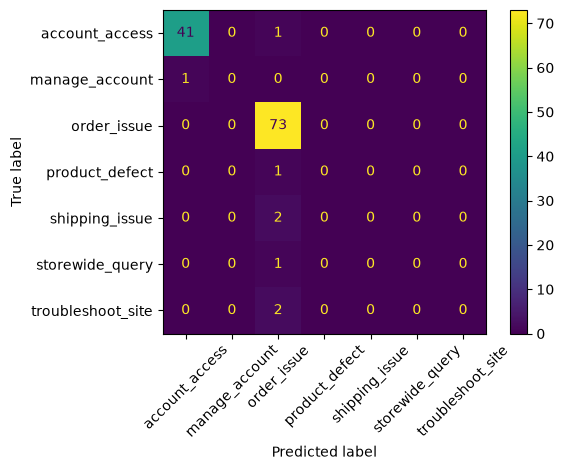

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def label_confusion(df, pred_col="pred_intent", true_col="true_flow"):
    mask = df[pred_col].notna()
    
    y_true = df.loc[mask, true_col]
    y_pred = df.loc[mask, pred_col]
    
    cm = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=sorted(set(y_true) | set(y_pred))
    )
    
    disp.plot(xticks_rotation=45)
    plt.tight_layout()
    plt.show()

label_confusion(df=intent_df, pred_col="pred_intent", true_col="true_flow")

## 5. Discover candidate new intents

Clustering runs only on unmatched conversations.

In [19]:
intent_topics, intent_topic_ids, intent_topic_model = discover_topics(unmatched_items)
display(intent_topics)

new_intent_clusters: list[dict] = []
if not intent_topics.empty:
    for row in intent_topics.itertuples():
        if not row.cohesive_enough:
            continue
        members = [by_id[i] for i in row.member_ids]
        new_intent_clusters.append(
            {
                "topic": int(row.topic),
                "n": int(row.n),
                "descriptor": row.descriptor,
                "items": members,
            }
        )
print("candidate new intents", [(c["topic"], c["n"], c["descriptor"]) for c in new_intent_clusters])

,topic,n,descriptor,cohesive_enough,offline_majority,offline_purity,member_ids
0,0,13,"try, website, slow, tabs, running, tried, clos...",True,troubleshoot_site/slow_speed,0.92,"[181, 110, 131, 152, 186, 201, 241, 363, 496, ..."
1,1,10,"check, know, status, number, credit, code, sur...",True,account_access/recover_username,0.20,"[532, 552, 297, 165, 239, 122, 627, 268, 1416,..."


candidate new intents [(0, 13, 'try, website, slow, tabs, running, tried, close, problem'), (1, 10, 'check, know, status, number, credit, code, sure, did')]


## 6. Subflow classification inside each assigned known intent

Prototypes are that intent’s seeded subflows only.

In [39]:
assigned_df = intent_df[intent_df["pred_intent"].isin(INTENT_NAMES)].copy()
subflow_frames = []
for flow, subflows in SEED_SUBFLOWS.items():
    part = assigned_df[assigned_df["pred_intent"] == flow]
    if part.empty:
        print(flow, "n assigned=0")
        continue
    items = [by_id[i] for i in part["conversation_id"]]
    embs = embed_items(items)
    sf_c = classify_against(embs, subflow_centroid[flow], subflows).add_prefix("subflow_centroid_")
    sf_g = classify_against(embs, subflow_guideline[flow], subflows).add_prefix("subflow_guideline_")
    block = pd.concat([part.reset_index(drop=True), sf_c, sf_g], axis=1)
    block["subflow_assigned"] = apply_fit_rule(
        block["subflow_centroid_fits"], block["subflow_guideline_fits"]
    )
    block["pred_subflow"] = [
        resolve_label(
            bool(r.subflow_centroid_fits),
            r.subflow_centroid_pred,
            r.subflow_centroid_sim,
            bool(r.subflow_guideline_fits),
            r.subflow_guideline_pred,
            r.subflow_guideline_sim,
        )
        for r in block.itertuples()
    ]
    subflow_frames.append(block)
    print(f"\n{flow} assigned n={len(block)} unclassified n={(~block.subflow_assigned).sum()}")
    display(
        block.groupby(
            ["true_subflow", "pred_subflow", "subflow_centroid_pred", "subflow_guideline_pred", "subflow_assigned"],
            dropna=False,
        )
        .size()
        .reset_index(name="n")
    )

subflow_df = pd.concat(subflow_frames, ignore_index=True) if subflow_frames else pd.DataFrame()
if not subflow_df.empty:
    display(
        subflow_df[
            [
                "conversation_id",
                "pred_intent",
                "true_subflow",
                "subflow_centroid_pred",
                "subflow_centroid_sim",
                "subflow_centroid_fits",
                "subflow_guideline_pred",
                "subflow_guideline_sim",
                "subflow_guideline_fits",
                "pred_subflow",
            ]
        ]
    )


account_access assigned n=42 unclassified n=3


,true_subflow,pred_subflow,subflow_centroid_pred,subflow_guideline_pred,subflow_assigned,n
0,manage_change_address,recover_username,recover_username,recover_username,True,1
1,recover_password,recover_password,recover_password,recover_password,True,13
2,recover_password,recover_password,recover_password,reset_2fa,True,2
3,recover_username,recover_username,recover_username,recover_username,True,12
4,recover_username,NaN,recover_username,recover_username,False,1
5,reset_2fa,reset_2fa,reset_2fa,recover_password,True,2
6,reset_2fa,reset_2fa,reset_2fa,reset_2fa,True,9
7,reset_2fa,NaN,recover_password,recover_password,False,1
8,reset_2fa,NaN,reset_2fa,recover_password,False,1



order_issue assigned n=80 unclassified n=19


,true_subflow,pred_subflow,subflow_centroid_pred,subflow_guideline_pred,subflow_assigned,n
0,cost,NaN,manage_upgrade,manage_cancel,False,1
1,manage_cancel,manage_cancel,manage_cancel,manage_cancel,True,15
2,manage_upgrade,manage_upgrade,manage_upgrade,manage_upgrade,True,12
3,manage_upgrade,NaN,manage_upgrade,manage_upgrade,False,3
4,missing,manage_cancel,manage_cancel,manage_upgrade,True,1
5,pricing_3,NaN,manage_cancel,manage_upgrade,False,1
6,refund_initiate,manage_cancel,manage_cancel,manage_cancel,True,1
7,reset_2fa,NaN,manage_upgrade,manage_upgrade,False,1
8,slow_speed,manage_cancel,manage_cancel,manage_upgrade,True,1
9,slow_speed,NaN,manage_cancel,status_mystery_fee,False,1


,conversation_id,pred_intent,true_subflow,subflow_centroid_pred,subflow_centroid_sim,subflow_centroid_fits,subflow_guideline_pred,subflow_guideline_sim,subflow_guideline_fits,pred_subflow
0,138,account_access,recover_username,recover_username,0.817,True,recover_username,0.437,False,recover_username
1,163,account_access,recover_username,recover_username,0.837,True,recover_username,0.491,False,recover_username
2,178,account_access,recover_username,recover_username,0.854,True,recover_username,0.559,False,recover_username
3,250,account_access,recover_username,recover_username,0.853,True,recover_username,0.573,False,recover_username
4,313,account_access,recover_username,recover_username,0.839,True,recover_username,0.509,False,recover_username
...,...,...,...,...,...,...,...,...,...,...
117,1713,order_issue,status_payment_method,status_mystery_fee,0.633,False,manage_upgrade,0.463,False,NaN
118,1749,order_issue,status_payment_method,manage_upgrade,0.631,False,manage_upgrade,0.504,False,NaN
119,1890,order_issue,status_payment_method,status_delivery_time,0.716,True,manage_upgrade,0.416,False,status_delivery_time
120,244,order_issue,slow_speed,manage_cancel,0.644,True,manage_upgrade,0.380,False,manage_cancel


In [22]:
subflow_df.head()

,conversation_id,role,true_flow,true_subflow,opening,intent_centroid_pred,intent_centroid_sim,intent_centroid_margin,intent_centroid_fits,intent_guideline_pred,...,subflow_centroid_pred,subflow_centroid_sim,subflow_centroid_margin,subflow_centroid_fits,subflow_guideline_pred,subflow_guideline_sim,subflow_guideline_margin,subflow_guideline_fits,subflow_assigned,pred_subflow
0,138,seed,account_access,recover_username,"Hi, I can't access my account",account_access,0.781,0.258,True,account_access,...,recover_username,0.817,0.069,False,recover_username,0.437,0.037,False,False,NaN
1,163,seed,account_access,recover_username,I can't access my account,account_access,0.814,0.303,True,account_access,...,recover_username,0.837,0.069,False,recover_username,0.491,0.045,False,False,NaN
2,178,seed,account_access,recover_username,"My name is David Williams, and I have an order...",account_access,0.818,0.192,True,account_access,...,recover_username,0.854,0.109,True,recover_username,0.559,0.126,False,True,recover_username
3,250,seed,account_access,recover_username,Hi I want to check on an order status on the w...,account_access,0.824,0.214,True,account_access,...,recover_username,0.853,0.095,False,recover_username,0.573,0.077,False,False,NaN
4,313,seed,account_access,recover_username,"Hello, I wanted to check the status of a recen...",account_access,0.763,0.107,True,order_issue,...,recover_username,0.839,0.166,True,recover_username,0.509,0.133,False,True,recover_username


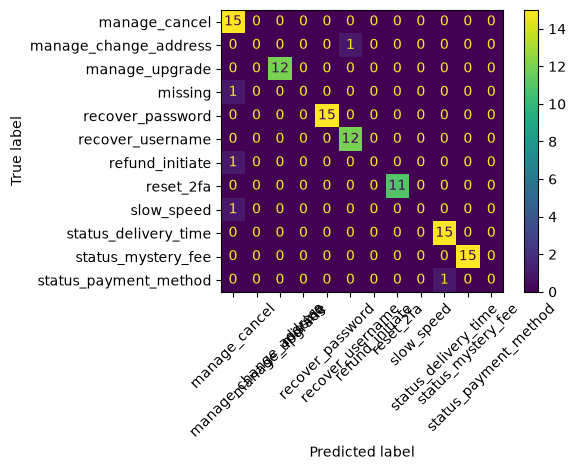

,count,pct
label_result,,
Correct,95,77.9
No label,22,18.0
Mislabelled,5,4.1


In [40]:
label_confusion(df=subflow_df, pred_col="pred_subflow", true_col="true_subflow")
label_summary(df=subflow_df, pred_col="pred_subflow", true_col="true_subflow")

## 7. Discover candidate new subflows

Same `discover_topics` on unclassified conversations **inside each known intent**.

In [41]:
new_subflow_clusters: list[dict] = []
for flow in INTENT_NAMES:
    if subflow_df.empty:
        continue
    leftover = subflow_df[(subflow_df["pred_intent"] == flow) & (~subflow_df["subflow_assigned"])]
    leftover_items = [by_id[i] for i in leftover["conversation_id"]]
    print(f"\n--- unclassified under {flow}: n={len(leftover_items)} ---")
    table, _, _ = discover_topics(leftover_items)
    display(table)
    if table.empty:
        continue
    for row in table.itertuples():
        if not row.cohesive_enough:
            continue
        new_subflow_clusters.append(
            {
                "intent": flow,
                "topic": int(row.topic),
                "n": int(row.n),
                "descriptor": row.descriptor,
                "member_ids": list(row.member_ids),
            }
        )
print("candidate new subflows", new_subflow_clusters)


--- unclassified under account_access: n=3 ---
skip clustering: n=3 < min_to_cluster=5


""



--- unclassified under order_issue: n=19 ---


,topic,n,descriptor,cohesive_enough,offline_majority,offline_purity,member_ids
0,0,10,"payment, change, method, information, payment ...",True,order_issue/status_payment_method,0.40,"[661, 278, 448, 757, 194, 279, 572, 1125, 1508..."
1,1,9,"payment, method, payment method, status, card,...",True,order_issue/status_payment_method,0.89,"[316, 424, 446, 679, 893, 1103, 1713, 1749, 523]"


candidate new subflows [{'intent': 'order_issue', 'topic': 0, 'n': 10, 'descriptor': 'payment, change, method, information, payment method, item, like, shipping', 'member_ids': [661, 278, 448, 757, 194, 279, 572, 1125, 1508, 1671]}, {'intent': 'order_issue', 'topic': 1, 'n': 9, 'descriptor': 'payment, method, payment method, status, card, sure, just, check', 'member_ids': [316, 424, 446, 679, 893, 1103, 1713, 1749, 523]}]


## 8. Subflows inside each candidate new intent

No seeded subflows. Run the same clustering on that topic’s members.

In [42]:
for cluster in new_intent_clusters:
    print(f"\n--- new intent topic {cluster['topic']} n={cluster['n']} ---")
    print("descriptor:", cluster["descriptor"])
    table, _, _ = discover_topics(cluster["items"])
    display(table)


--- new intent topic 0 n=13 ---
descriptor: try, website, slow, tabs, running, tried, close, problem


,topic,n,descriptor,cohesive_enough,offline_majority,offline_purity,member_ids
0,0,8,"try, website, slow, problem, tried, just, sure...",True,troubleshoot_site/slow_speed,0.88,"[181, 110, 186, 201, 363, 496, 534, 537]"
1,1,5,"slow, try, running, tabs, website, speed, clos...",True,troubleshoot_site/slow_speed,1.00,"[131, 152, 241, 522, 691]"



--- new intent topic 1 n=10 ---
descriptor: check, know, status, number, credit, code, sure, did


,topic,n,descriptor,cohesive_enough,offline_majority,offline_purity,member_ids
0,-1,10,,False,account_access/recover_username,0.2,"[532, 552, 297, 165, 239, 122, 627, 268, 1416,..."


## 9. Action sequences on discovered clusters

Inspection only. Exact sequence identity is usually noisy; button sets are listed too.

In [43]:
def action_report(items: list[dict], title: str) -> None:
    seqs = Counter(action_names(c) for c in items)
    print(f"\n{title}  n={len(items)}  unique_seqs={len(seqs)}")
    for seq, n in seqs.most_common(5):
        print(f"  {n:3d}  {seq}")
    buttons = Counter(name for c in items for name in set(action_names(c)))
    print("  button presence", dict(buttons.most_common()))


for cluster in new_subflow_clusters:
    members = [by_id[i] for i in cluster["member_ids"]]
    action_report(members, f"new subflow under {cluster['intent']} topic {cluster['topic']}")

for cluster in new_intent_clusters:
    action_report(cluster["items"], f"new intent topic {cluster['topic']}")
    print("  canonical kb for probe intent subflow (offline)", kb.get(PROBE_INTENT[1]))

print("\ndone. change MIN_SIM / MIN_MARGIN / FIT_RULE / MIN_TOPIC_N and re-run.")


new subflow under order_issue topic 0  n=10  unique_seqs=9
    2  ('pull-up-account', 'verify-identity', 'shipping-status')
    1  ('pull-up-account', 'verify-identity', 'ask-the-oracle')
    1  ('shipping-status', 'validate-purchase', 'shipping-status', 'shipping-status', 'update-order')
    1  ('pull-up-account', 'verify-identity', 'verify-identity', 'validate-purchase', 'update-order', 'search-faq', 'search-timing', 'enter-details', 'membership', 'search-faq', 'search-membership', 'shipping-status', 'shipping-status')
    1  ('pull-up-account', 'validate-purchase', 'ask-the-oracle', 'shipping-status')
  button presence {'pull-up-account': 8, 'verify-identity': 7, 'update-order': 6, 'shipping-status': 6, 'validate-purchase': 4, 'ask-the-oracle': 3, 'enter-details': 2, 'search-faq': 1, 'search-membership': 1, 'search-timing': 1, 'membership': 1}

new subflow under order_issue topic 1  n=9  unique_seqs=9
    1  ('verify-identity', 'shipping-status')
    1  ('verify-identity', 'pull-up